In [1]:
%load_ext autoreload
%autoreload 2
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch

from tqdm.notebook import tqdm

from scFM_density_estimation.models import *
from scFM_density_estimation.datamodules import *
from scFM_density_estimation.utils import *

In [40]:
def prepare_batch(X, C, num_classes, num_conditions, batch_size, device):
    indices = np.random.randint(X.shape[0], size=batch_size)
    x1 = torch.from_numpy(X[indices]).float().to(device)
    
    cond = []
    for i in range(num_conditions):
        cond.append(torch.nn.functional.one_hot(torch.from_numpy(C[:, i][indices]).long(),
                                                num_classes=num_classes[i]).float()
                   )
    cond = torch.cat(cond, dim=1).to(device)
    
    return x1, cond

def prepare_val_batch(X, C, num_classes, num_conditions, device):
    x1 = torch.from_numpy(X).float().to(device)
    
    cond = []
    for i in range(num_conditions):
        cond.append(torch.nn.functional.one_hot(torch.from_numpy(C[:, i]).long(),
                                                num_classes=num_classes[i]).float()
                   )
    cond = torch.cat(cond, dim=1).to(device)
    
    return x1, cond

def weighted_wasserstein(X, C, num_classes, model):
    ws_dist = 0
    combined_conditions = C.cpu().numpy()
    unique_conditions = np.unique(combined_conditions, axis=0)
    
    for condition in unique_conditions:
        mask = np.all(combined_conditions == condition, axis=1)
        generated_samples = model.run_simulation(X[mask], C[mask], n_steps=100)
        ws_dist += wasserstein(X[mask], generated_samples) * np.sum(mask)

    return ws_dist / C.shape[0]

In [74]:
adata = sc.read_h5ad("./data/pbmc3k.h5ad")
X = adata.obsm["X_pca"][:, :10]
C = np.stack([adata.obs["louvain"].cat.codes.values.copy()], axis=1)

  0%|          | 0/30000 [00:00<?, ?it/s]

Step 1000, EMA Loss: 5.766
Step 2000, EMA Loss: 3.609
Step 3000, EMA Loss: 2.802
Step 4000, EMA Loss: 2.496
Step 5000, EMA Loss: 2.366
Step 6000, EMA Loss: 2.312
Step 7000, EMA Loss: 2.290
Step 8000, EMA Loss: 2.252
Step 9000, EMA Loss: 2.229
Step 10000, EMA Loss: 2.213
Step 10000, Weighted Wasserstein distance: 2.900


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


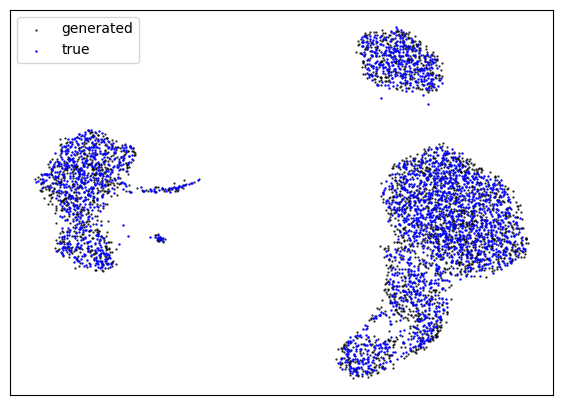

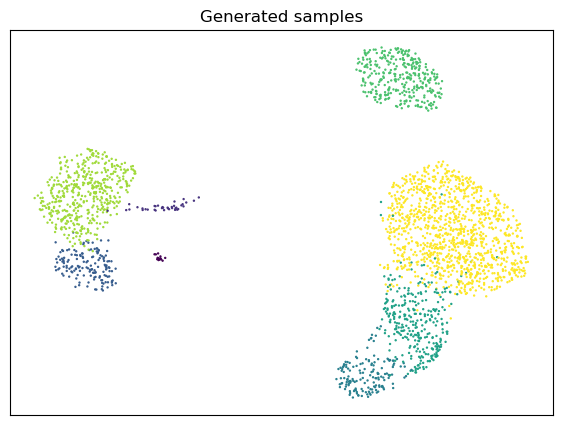

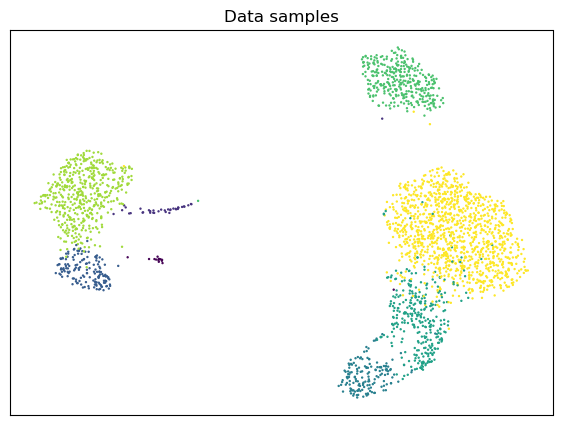

Step 11000, EMA Loss: 2.202
Step 12000, EMA Loss: 2.180
Step 13000, EMA Loss: 2.163
Step 14000, EMA Loss: 2.146
Step 15000, EMA Loss: 2.132
Step 16000, EMA Loss: 2.118
Step 17000, EMA Loss: 2.104
Step 18000, EMA Loss: 2.094
Step 19000, EMA Loss: 2.084
Step 20000, EMA Loss: 2.075
Step 20000, Weighted Wasserstein distance: 2.754


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


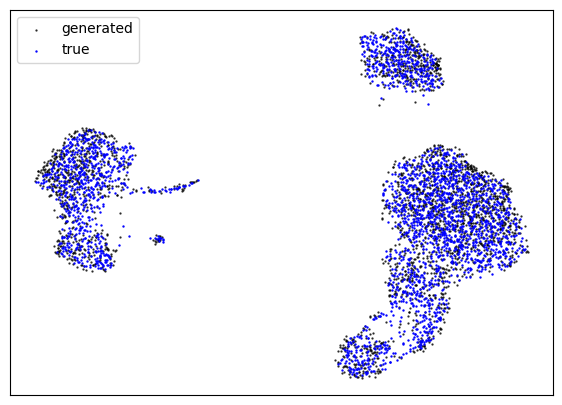

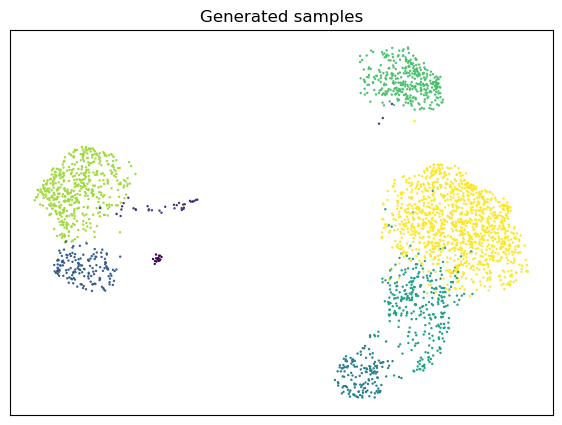

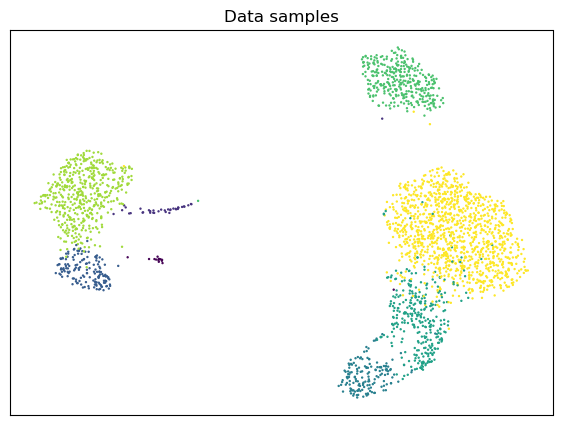

Step 21000, EMA Loss: 2.061
Step 22000, EMA Loss: 2.056
Step 23000, EMA Loss: 2.042
Step 24000, EMA Loss: 2.036
Step 25000, EMA Loss: 2.032
Step 26000, EMA Loss: 2.019
Step 27000, EMA Loss: 2.020
Step 28000, EMA Loss: 2.011
Step 29000, EMA Loss: 1.995
Step 30000, EMA Loss: 1.997
Step 30000, Weighted Wasserstein distance: 2.504


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


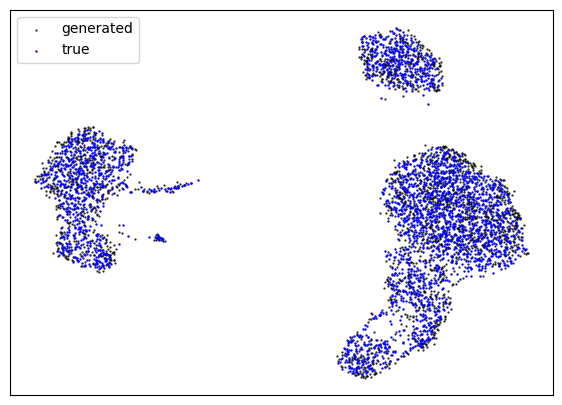

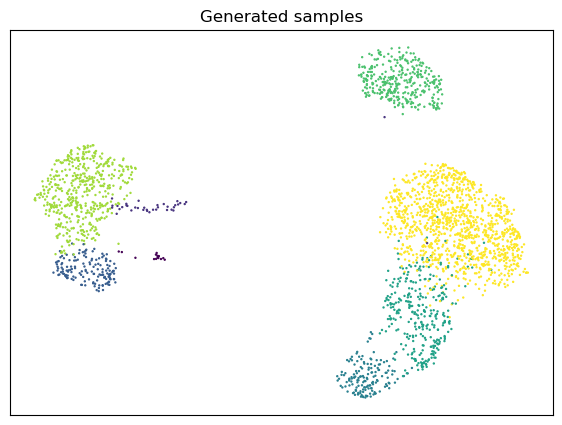

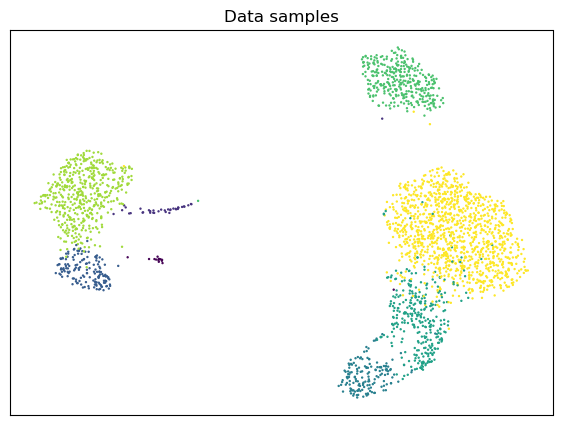

In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
cond_dims = [8]
num_cond = 1
dim = 10
alpha = 0.999
ema_loss = None
use_ot_sampler = False
model = ConditionalFlowMatching(input_dim=dim, hidden_dims=[1024, 1024, 1024, 1024],
                                   cond_dim=np.sum(cond_dims), use_encoder=False,
                                   use_ot_sampler=use_ot_sampler).to(device)
optimizer = model.configure_optimizers()

for k in tqdm(range(30000)):
    optimizer.zero_grad()

    x1, cond = prepare_batch(X, C, cond_dims, num_cond, batch_size, device)
    loss = model.shared_step(x1, cond)
    
    loss.backward()
    optimizer.step()

    if ema_loss is None:
        ema_loss = loss.item()
    else:
        ema_loss = alpha * ema_loss + (1 - alpha) * loss.item() 

    if (k + 1) % 1000 == 0:
        print(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")
    
    if (k + 1) % 10000 == 0:
        x1, cond = prepare_val_batch(X, C, cond_dims, num_cond, device)
        ws_dist = weighted_wasserstein(x1, cond, cond_dims, model)
        print(f"Step {k+1}, Weighted Wasserstein distance: {ws_dist:.3f}")

    if (k + 1) % 10000 == 0:
        x1, cond = prepare_val_batch(X, C, cond_dims, num_cond, device)
        generated_samples = model.run_simulation(x1, cond, n_steps=100)

        model.get_umap_reducer()
        data_umap = model.reducer.fit_transform(x1.cpu().numpy())
        generated_umap = model.reducer.transform(generated_samples.cpu().numpy())
        
        plot_simulation(generated_umap, data_umap, cond.cpu().numpy(), size=0.5, plot_size=(7, 5))

In [62]:
torch.save(model.state_dict(), "./weights/pbmc_no_ot_new.ckpt")

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
cond_dims = [8]
num_cond = 1
dim = 50
use_ot_sampler = False
model = ConditionalFlowMatching(input_dim=dim, hidden_dims=[1024, 1024, 1024, 1024],
                                   cond_dim=np.sum(cond_dims), use_encoder=False,
                                   use_ot_sampler=use_ot_sampler).to(device)
model.load_state_dict(torch.load("./weights/pbmc_no_ot_new.ckpt",  weights_only=False))

<All keys matched successfully>

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


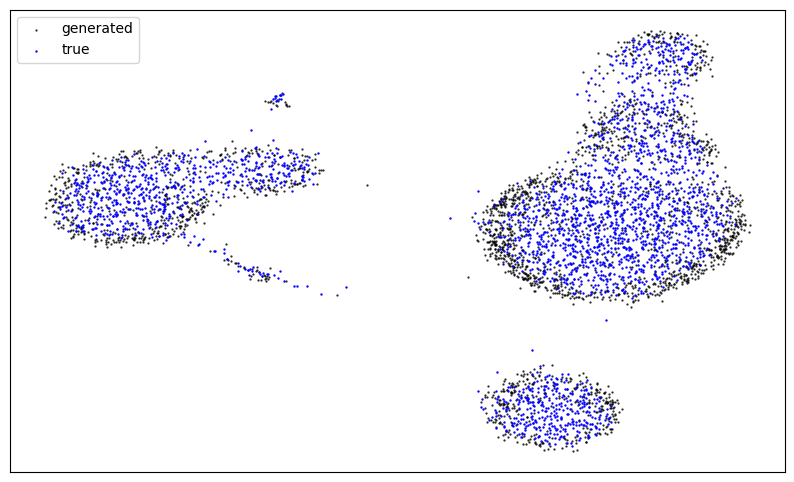

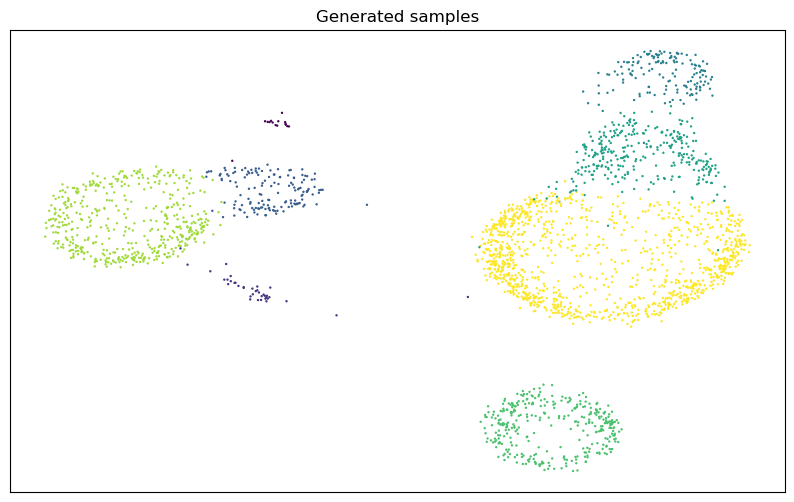

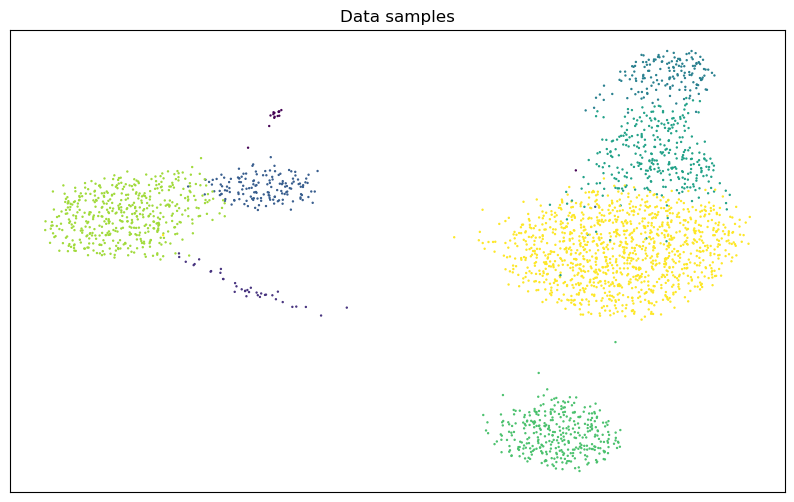

In [64]:
x1, cond = prepare_val_batch(X, C, cond_dims, num_cond, device)
generated_samples = model.run_simulation(x1, cond, n_steps=100)

model.get_umap_reducer()
data_umap = model.reducer.fit_transform(x1.cpu().numpy())
generated_umap = model.reducer.transform(generated_samples.cpu().numpy())

plot_simulation(generated_umap, data_umap, cond.cpu().numpy(), size=0.5, plot_size=(10, 6))

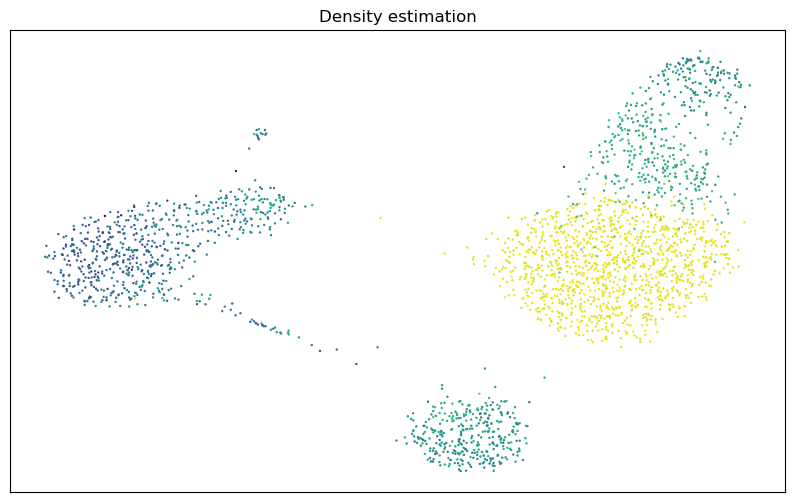

In [65]:
condition = [0]
x1, cond = prepare_val_batch(X, C, cond_dims, num_cond, device)
cond = []
for i in range(num_cond):
    cond.append(torch.from_numpy(np.array([1 if j == condition[i] else 0 for j in range(cond_dims[i])]
                                         ).reshape(1, -1)).float().expand(x1.shape[0], cond_dims[i])
               )
cond = torch.cat(cond, dim=1).to(device)
log_density = model.estimate_log_density(x1, cond, n_steps=100)

model.get_umap_reducer(None)
data_umap = model.reducer.fit_transform(x1.cpu().numpy())

plot_densities(data_umap, log_density, size=0.5, plot_size=(10, 6))

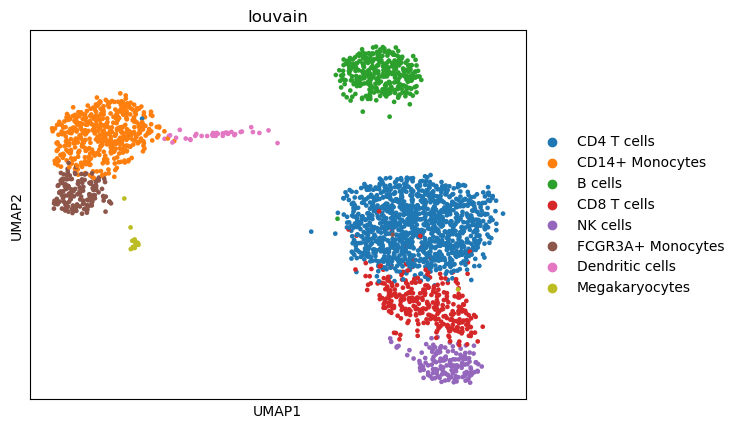

In [66]:
sc.pl.umap(adata, color="louvain")

  0%|          | 0/8 [00:00<?, ?it/s]

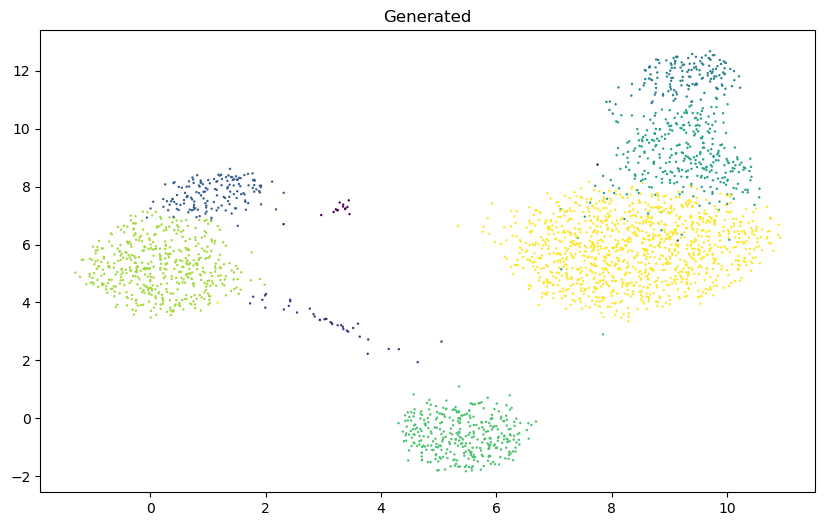

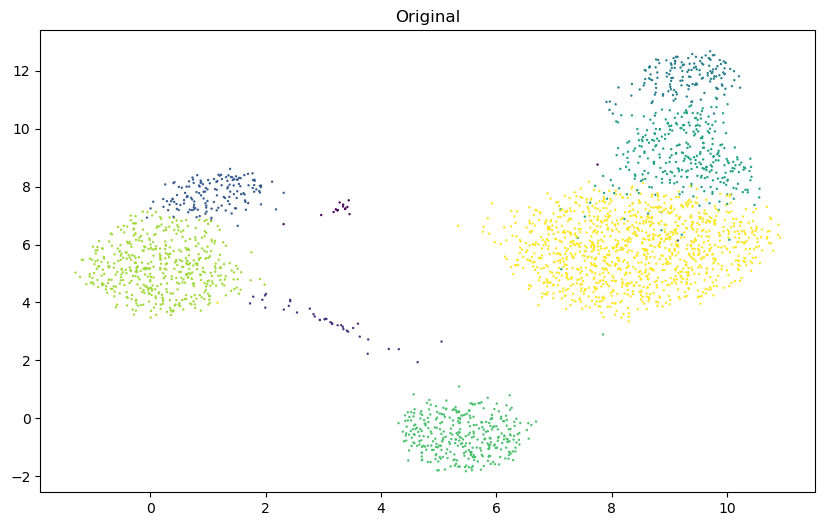

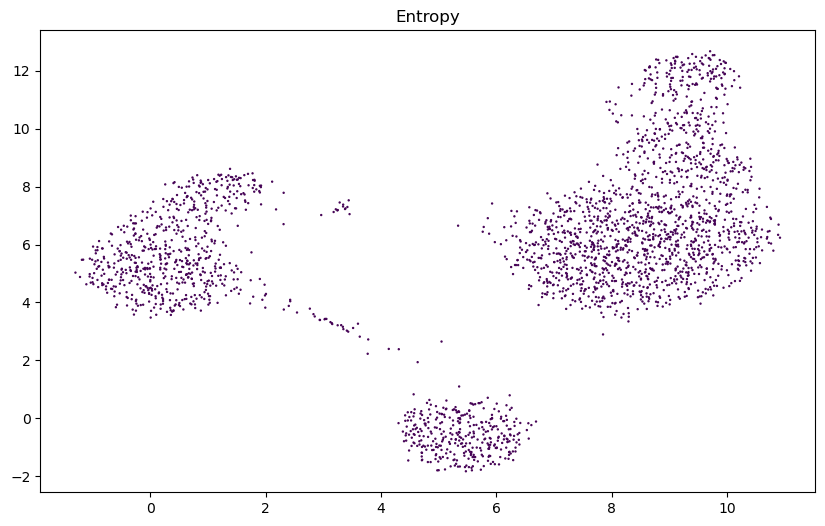

In [67]:
log_density = []
x1, cond_orig = prepare_val_batch(X, C, cond_dims, num_cond, device)
unique_conditions = np.unique(cond_orig.cpu().numpy(), axis=0)
for condition in tqdm(unique_conditions):
    cond = torch.from_numpy(condition).expand(cond_orig.shape).float().to(device)
    log_density.append(model.estimate_log_density(x1, cond, n_steps=100).reshape(-1, 1))
log_density = np.concatenate(log_density, axis=1)
color = np.argmax(log_density, axis=1)

def softmax(x):
    e_x = np.exp(x)
    return e_x / e_x.sum(axis=-1, keepdims=True)
    
entropy = np.max(softmax(log_density), axis=1)
entropy = entropy * (1 - entropy)

color_orig = np.zeros_like(color)
for i in range(unique_conditions.shape[0]):
    mask = np.all(cond_orig.cpu().numpy() == unique_conditions[i], axis=1)
    color_orig[mask] = i

model.get_umap_reducer(None)
data_umap = model.reducer.fit_transform(x1.cpu().numpy())

plt.figure(figsize=(10, 6))
plt.title("Generated")
plt.scatter(data_umap[:, 0], data_umap[:, 1], s=0.5, c=color)
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Original")
plt.scatter(data_umap[:, 0], data_umap[:, 1], s=0.5, c=color_orig)
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Entropy")
plt.scatter(data_umap[:, 0], data_umap[:, 1], s=0.5, c=entropy, cmap="viridis")
plt.show()

In [71]:
np.sum(color == color_orig) / color.shape[0]

1.0

In [72]:
np.max(log_density)

8.958717

(array([   0.,    0.,    0.,    0.,    0., 2638.,    0.,    0.,    0.,
           0.]),
 array([-0.5       , -0.40000001, -0.30000001, -0.2       , -0.1       ,
         0.        ,  0.1       ,  0.2       ,  0.30000001,  0.40000001,
         0.5       ]),
 <BarContainer object of 10 artists>)

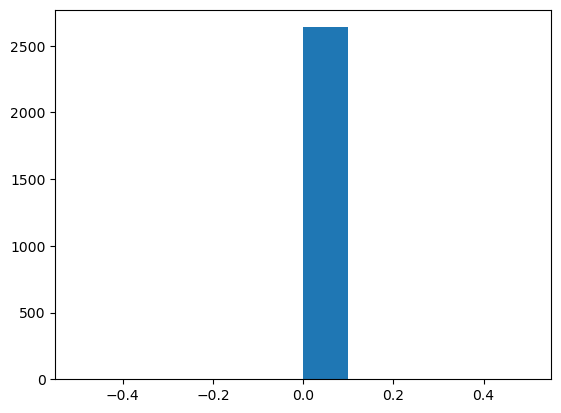

In [73]:
plt.hist(entropy)